# CAFÉ — point-and-shoot causal imputation

**One line fills the gaps. No config. No look-ahead. pandas *or* polars.**

```python
filled = cafe.impute(df)   # that's it
```

CAFÉ (*Causal Adaptive Factor Estimation*) is a zero-config, CPU-only imputer for
time-series and panel data. You hand it a raw DataFrame — dates, strings, numbers,
whatever — and it hands the same DataFrame back with the **numeric gaps filled**,
using *only past + contemporaneous* information (never the future). From the *same*
pass it also gives you uncertainty, latent factors, anomaly scores, a decomposition,
a dependency network, and forecasts.

This tutorial uses the real **ETTh1** electricity-transformer dataset (hourly sensors)
and drives everything through **polars** — then shows the identical one-liner on pandas.

## 0 · Setup

In [1]:
# pip install cafe-impute  (here we run straight from the repo)
import sys, pathlib
_src = pathlib.Path.cwd().parent / "src"
if _src.exists() and str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import cafe

plt.rcParams.update({"figure.figsize": (10, 3.2), "axes.grid": True, "grid.alpha": 0.25})
print("CAFÉ version:", cafe.__version__)

CAFÉ version: 0.1.0


## 1 · The 30-second version

Load the raw CSV with polars. It has a `date` **string** column plus 7 numeric
sensors — a perfectly ordinary, messy real-world frame. We punch random holes into
the numeric columns (keeping the truth aside so we can score the fill later).

In [2]:
raw = pl.read_csv("../data/ETTh1.csv").head(1500)         # real hourly sensor data
num_cols = [c for c, dt in raw.schema.items() if dt.is_numeric()]
print("shape:", raw.shape, "| numeric:", num_cols, "| passthrough:", ['date'])

# 12% missing-completely-at-random on the numeric columns, via polars expressions
rng = np.random.default_rng(0)
masks = {c: rng.random(raw.height) < 0.12 for c in num_cols}
gappy = raw.with_columns([
    pl.when(pl.Series(masks[c])).then(None).otherwise(pl.col(c)).alias(c)
    for c in num_cols
])
gappy.head(5)

shape: (1500, 8) | numeric: ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT'] | passthrough: ['date']


date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
str,f64,f64,f64,f64,f64,f64,f64
"""2016-07-01 00:00:00""",5.827,null,1.599,0.462,4.203,1.34,30.531
"""2016-07-01 01:00:00""",5.693,2.076,1.492,0.426,4.142,1.371,27.787001
"""2016-07-01 02:00:00""",null,null,1.279,0.355,null,1.218,27.787001
"""2016-07-01 03:00:00""",null,null,1.279,0.391,3.807,1.279,25.044001
"""2016-07-01 04:00:00""",5.358,null,1.492,0.462,3.868,1.279,null


Now the whole point of the library — **one call**:

In [3]:
filled = cafe.impute(gappy)          # <-- point and shoot

print("nulls before:", gappy.null_count().sum_horizontal().item(),
      " after:", filled.null_count().sum_horizontal().item())
print("returned type:", type(filled).__name__, "| columns:", filled.columns)
filled.head(5)

nulls before: 1265  after: 0
returned type: DataFrame | columns: ['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']


date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
str,f64,f64,f64,f64,f64,f64,f64
"""2016-07-01 00:00:00""",5.827,1.174542,1.599,0.462,4.203,1.34,30.531
"""2016-07-01 01:00:00""",5.693,2.076,1.492,0.426,4.142,1.371,27.787001
"""2016-07-01 02:00:00""",5.55217,4.07817,1.279,0.355,4.037671,1.218,27.787001
"""2016-07-01 03:00:00""",5.743858,2.059859,1.279,0.391,3.807,1.279,25.044001
"""2016-07-01 04:00:00""",5.358,2.061438,1.492,0.462,3.868,1.279,24.131155


Notice what *just happened* with zero configuration:

* the **`date` column passed straight through** (CAFÉ only touches numeric columns),
* **column order is preserved**, the type is still a `polars.DataFrame`,
* every numeric gap is filled — no rank, no window, no seasonality knob to set.

That is the entire happy path.

## 2 · The moat — provably no look-ahead

Almost every imputer fills `X[t]` using the *whole* series, including the future —
silently leaking look-ahead into any sequential pipeline (a backtest, a live monitor).
CAFÉ fills `X[t]` from **only data up to `t`**. We can *prove* it: impute a prefix, then
impute the full series and slice to that prefix — the answers are **bit-identical**.

In [4]:
X = gappy.select(num_cols).to_numpy()        # numeric matrix with NaNs
t = 800
prefix_only = np.asarray(cafe.impute(X[:t]))             # saw only the first t rows
full_then_cut = np.asarray(cafe.impute(X))[:t]           # saw everything, then sliced

max_diff = np.abs(prefix_only - full_then_cut).max()
print(f"max difference over {prefix_only.size:,} cells: {max_diff:.2e}")
assert max_diff == 0.0
print("✓ a past imputation does NOT change when the future arrives — backtest-safe.")

max difference over 5,600 cells: 0.00e+00
✓ a past imputation does NOT change when the future arrives — backtest-safe.


## 3 · How good is the fill?

Because we kept the ground truth, we can score the imputation on the **held-out
(masked) cells only**. We score **per column** (normalised MAE in std units, and
correlation) and then average — pooling sensors of different scales would inflate
correlation into a meaningless number, so we don't.

sensor    nMAE    corr
HUFL     0.208   0.944
HULL     0.324   0.898
MUFL     0.242   0.927
MULL     0.341   0.860
LUFL     0.389   0.820
LULL     1.290   0.649
OT       0.333   0.908
----------------------
mean     0.447   0.858


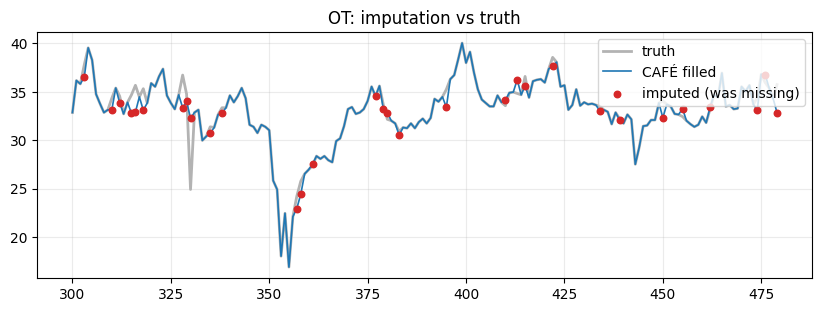

In [5]:
truth = raw.select(num_cols).to_numpy()
pred  = filled.select(num_cols).to_numpy()

rows = []
for j, c in enumerate(num_cols):
    m = masks[c]; t = truth[m, j]; p = pred[m, j]
    rows.append((c, np.abs(p - t).mean() / t.std(), np.corrcoef(t, p)[0, 1]))

print(f"{'sensor':6s} {'nMAE':>7s} {'corr':>7s}")
for c, mae, corr in rows:
    print(f"{c:6s} {mae:7.3f} {corr:7.3f}")
print("-" * 22)
print(f"{'mean':6s} {np.mean([r[1] for r in rows]):7.3f} "
      f"{np.mean([r[2] for r in rows]):7.3f}")

# eyeball one sensor
col = num_cols[-1]; j = num_cols.index(col); m = masks[col]
idx = np.arange(300, 480)
plt.plot(idx, truth[idx, j], lw=2, label="truth", color="0.7")
plt.plot(idx, pred[idx, j], lw=1.2, label="CAFÉ filled", color="C0")
hid = idx[m[idx]]
plt.scatter(hid, pred[hid, j], s=22, color="C3", zorder=5, label="imputed (was missing)")
plt.title(f"{col}: imputation vs truth"); plt.legend(loc="upper right"); plt.show()

## 4 · One pass, many outputs

The same forward pass that filled the gaps also produced everything a dynamic factor
model naturally yields. Grab the rich result with `CAFE().run(...)`.

In [6]:
res = cafe.CAFE().run(gappy)
res.params       # the four dials CAFÉ learned from the data (not set by you)

{'nu': 4.704650858365859, 'ar': 0.8658804853332569, 'effective_rank': 3}

**Per-cell uncertainty** — the posterior std widens where CAFÉ is guessing:

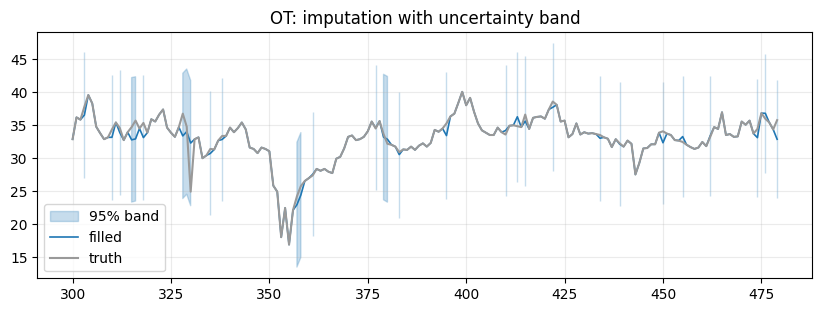

In [7]:
lower, upper = res.confidence_interval(z=1.96)
col = num_cols[-1]; j = num_cols.index(col); m = masks[col]
idx = np.arange(300, 480)
lo = lower.select(col).to_numpy().ravel(); hi = upper.select(col).to_numpy().ravel()
fillv = filled.select(col).to_numpy().ravel()
plt.fill_between(idx, lo[idx], hi[idx], alpha=0.25, color="C0", label="95% band")
plt.plot(idx, fillv[idx], color="C0", lw=1.2, label="filled")
plt.plot(idx, truth[idx, j], color="0.6", lw=1.5, label="truth")
plt.title(f"{col}: imputation with uncertainty band"); plt.legend(); plt.show()

**Anomaly score** — a free byproduct of the Student-t robust weights (causal):

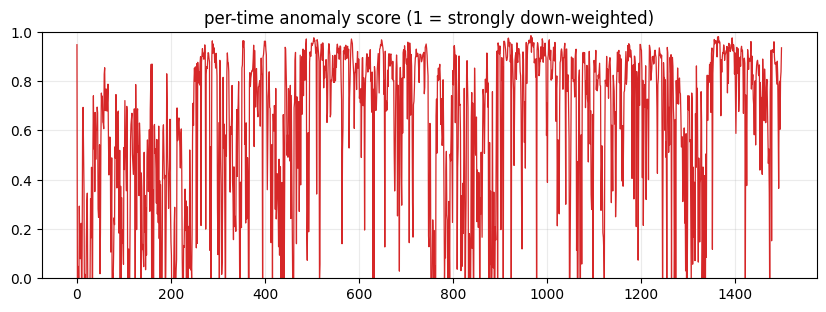

In [8]:
anom = np.asarray(res.anomaly_scores())
plt.plot(anom, lw=0.9, color="C3")
plt.title("per-time anomaly score (1 = strongly down-weighted)"); plt.ylim(0, 1); plt.show()

**Latent common factors** — the shared trends moving many sensors together:

effective rank ARD kept: 3


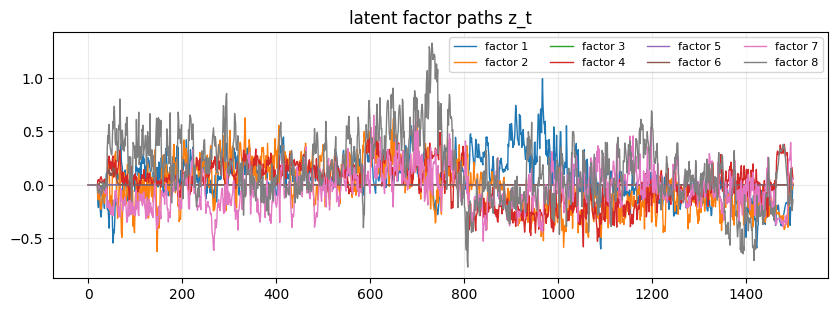

In [9]:
Z = res.factors()
for r in range(Z.shape[1]):
    plt.plot(Z[:, r], lw=1.0, label=f"factor {r+1}")
print("effective rank ARD kept:", res.effective_rank())
plt.title("latent factor paths z_t"); plt.legend(ncol=4, fontsize=8); plt.show()

**Additive decomposition** — every series as level + season + factor:

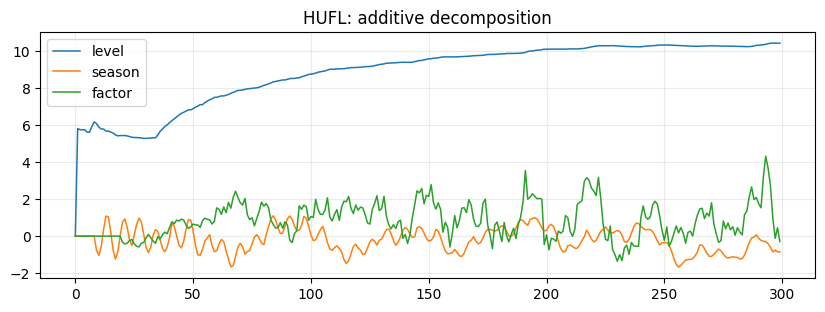

In [10]:
parts = res.decompose()
col = num_cols[0]
idx = np.arange(0, 300)
for name in ("level", "season", "factor"):
    plt.plot(idx, parts[name].select(col).to_numpy().ravel()[idx], lw=1.1, label=name)
plt.title(f"{col}: additive decomposition"); plt.legend(); plt.show()

**Dependency network** — residual correlations between sensors:

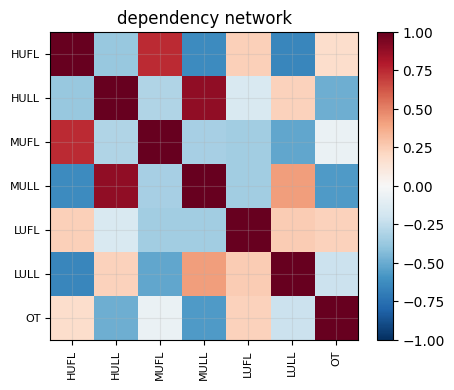

In [11]:
net = res.dependency_network()
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(net, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=90, fontsize=8)
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols, fontsize=8)
fig.colorbar(im, fraction=0.046); ax.set_title("dependency network"); plt.show()

## 5 · Forecasting = imputing the future

Forecasting is just imputing all-missing future rows with the same model and state —
no separate API, no retraining.

forecast block: (48, 7)


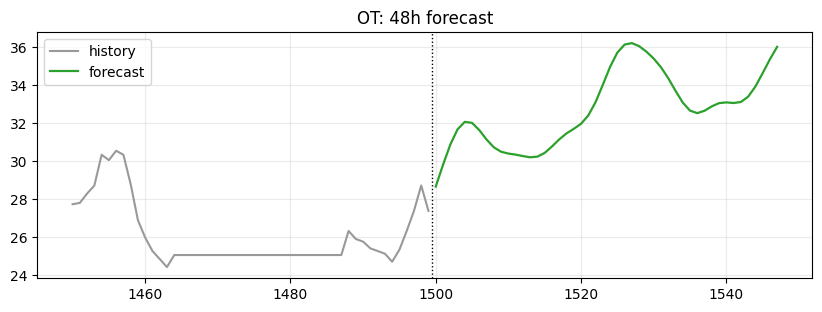

In [12]:
future = cafe.CAFE().forecast(gappy, horizon=48)   # 48 hours ahead
print("forecast block:", future.shape)
col = num_cols[-1]; j = num_cols.index(col)
hist = np.arange(1450, 1500)
plt.plot(hist, raw.select(col).to_numpy().ravel()[hist], color="0.6", label="history")
fut_idx = np.arange(1500, 1500 + 48)
plt.plot(fut_idx, future.select(col).to_numpy().ravel(), color="C2", lw=1.6, label="forecast")
plt.axvline(1499.5, color="k", ls=":", lw=1); plt.title(f"{col}: 48h forecast"); plt.legend(); plt.show()

## 6 · pandas? Identical one-liner.

CAFÉ is container-native. Hand it a pandas DataFrame with a datetime index (or a date
column) and the exact same call returns a pandas DataFrame, labels and dtypes intact.

In [13]:
import pandas as pd
pdf = gappy.to_pandas().set_index("date")     # datetime-ish index + numeric columns
out_pd = cafe.impute(pdf)                      # <-- same call
print(type(out_pd).__name__, "| nulls after:", int(out_pd.isna().sum().sum()))
out_pd.head(3)

DataFrame | nulls after: 0


,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.82700,1.174542,1.599,0.462,4.203000,1.340,30.531000
2016-07-01 01:00:00,5.69300,2.076000,1.492,0.426,4.142000,1.371,27.787001
2016-07-01 02:00:00,5.55217,4.078170,1.279,0.355,4.037671,1.218,27.787001


## Recap

| You wrote | You got |
|---|---|
| `cafe.impute(df)` | gaps filled, dates/strings preserved, same container, **no look-ahead** |
| `CAFE().run(df)` | `.uncertainty`, `.confidence_interval()`, `.factors()`, `.anomaly_scores()`, `.decompose()`, `.dependency_network()`, `.params` |
| `CAFE().forecast(df, h)` | h-step forecast from the same model |

Zero configuration, pure `numpy`/`scipy`, CPU-only — and backtest-safe by construction.

```bash
pip install cafe-impute
```